# Détection automatique de faux billets - ONCFM

## Contexte

L'Organisation nationale de lutte contre le faux-monnayage (ONCFM) souhaite mettre en place un algorithme de machine learning capable de différencier automatiquement les vrais des faux billets en euros, à partir de leurs caractéristiques géométriques.

## Données

Nous disposons d'un jeu de données contenant 1500 billets déjà scannés et labellisés (1000 vrais, 500 faux), décrits par six variables géométriques :

- length : longueur du billet (mm)
- height_left : hauteur du billet, côté gauche (mm)
- height_right : hauteur du billet, côté droit (mm)
- margin_up : marge supérieure entre le bord et l'image (mm)
- margin_low : marge inférieure entre le bord et l'image (mm)
- diagonal : diagonale du billet (mm)

## Objectif

Construire un algorithme capable de prédire si un billet est vrai ou faux à partir de ces six mesures. Quatre méthodes seront testées et comparées :

- Régression logistique
- K-nearest neighbors (KNN)
- Random Forest
- K-means

## Démarche

1. Exploration des données (analyse descriptive, visualisation, recherche de valeurs manquantes)
2. Prétraitement (séparation des variables, split train/test, standardisation)
3. Entraînement des quatre modèles
4. Évaluation et comparaison des performances
5. Sélection et sauvegarde du modèle final


In [1]:
import sys
print(sys.executable)

c:\Users\proga\miniconda3\python.exe


In [2]:
# Utilitaires
import os                                  # gestion des chemins de fichiers
import warnings
warnings.filterwarnings('ignore')          # masque les messages d'avertissement non bloquants

# Données et visualisation
import pandas as pd                        # manipulation des données tabulaires
import numpy as np                         # calculs numériques
import matplotlib.pyplot as plt            # visualisation de base
import seaborn as sns                      # visualisation statistique avancée

# Prétraitement
from sklearn.model_selection import train_test_split   # séparation train/test
from sklearn.preprocessing import StandardScaler        # standardisation des variables
from sklearn.impute import SimpleImputer                # imputation des valeurs manquantes

# Modèles de classification
from sklearn.linear_model import LogisticRegression     # régression logistique
from sklearn.neighbors import KNeighborsClassifier      # k plus proches voisins
from sklearn.ensemble import RandomForestClassifier     # forêt aléatoire
from sklearn.cluster import KMeans                      # clustering non supervisé

# Évaluation des modèles
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,   # métriques de performance
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,    # courbe ROC et matrice de confusion
    classification_report                                       # rapport de classification complet
)

# Sauvegarde du modèle
from sklearn.pipeline import make_pipeline   # chaînage prétraitement + modèle
import joblib                                # sauvegarde/chargement du modèle entraîné

## Chargement des données

Nous chargeons le fichier billets.csv contenant les 1500 billets scannés (1000 vrais, 500 faux). Nous vérifions ensuite la forme du jeu de données et son contenu.


In [3]:
df = pd.read_csv("../data/billets.csv", sep=";")   # lecture du fichier (séparateur point-virgule)
print(df.shape)                                     # nombre de lignes et colonnes
df.head()                                           # aperçu des premières lignes

(1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


### Vérification des types et des valeurs manquantes


In [4]:
df.info()   # types des colonnes, nombre de valeurs non nulles

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


### Statistiques descriptives

Nous calculons les statistiques descriptives de chaque variable géométrique (moyenne, écart-type, min, max, quartiles) afin d'avoir une première idée des ordres de grandeur et de détecter d'éventuelles valeurs aberrantes.


In [5]:
df.describe()   # statistiques descriptives des variables numériques

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


**Observation** : les statistiques descriptives ne révèlent pas de valeur aberrante. Les écarts-types sont faibles pour toutes les variables, ce qui est cohérent avec des billets standardisés. La seule anomalie est l'absence de 37 valeurs pour la variable margin_low, qui devra être traitée à l'étape de prétraitement.


### Répartition des vrais et faux billets

Nous vérifions l'équilibre des classes dans le jeu de données, c'est-à-dire le nombre de vrais et de faux billets.


In [6]:
df["is_genuine"].value_counts()          # nombre de vrais et faux billets
df["is_genuine"].value_counts(normalize=True)   # en pourcentage

is_genuine
True     0.666667
False    0.333333
Name: proportion, dtype: float64

### Distribution des variables

Nous visualisons la distribution de chaque variable géométrique, en distinguant les vrais et les faux billets, afin d'identifier celles qui semblent les plus discriminantes.


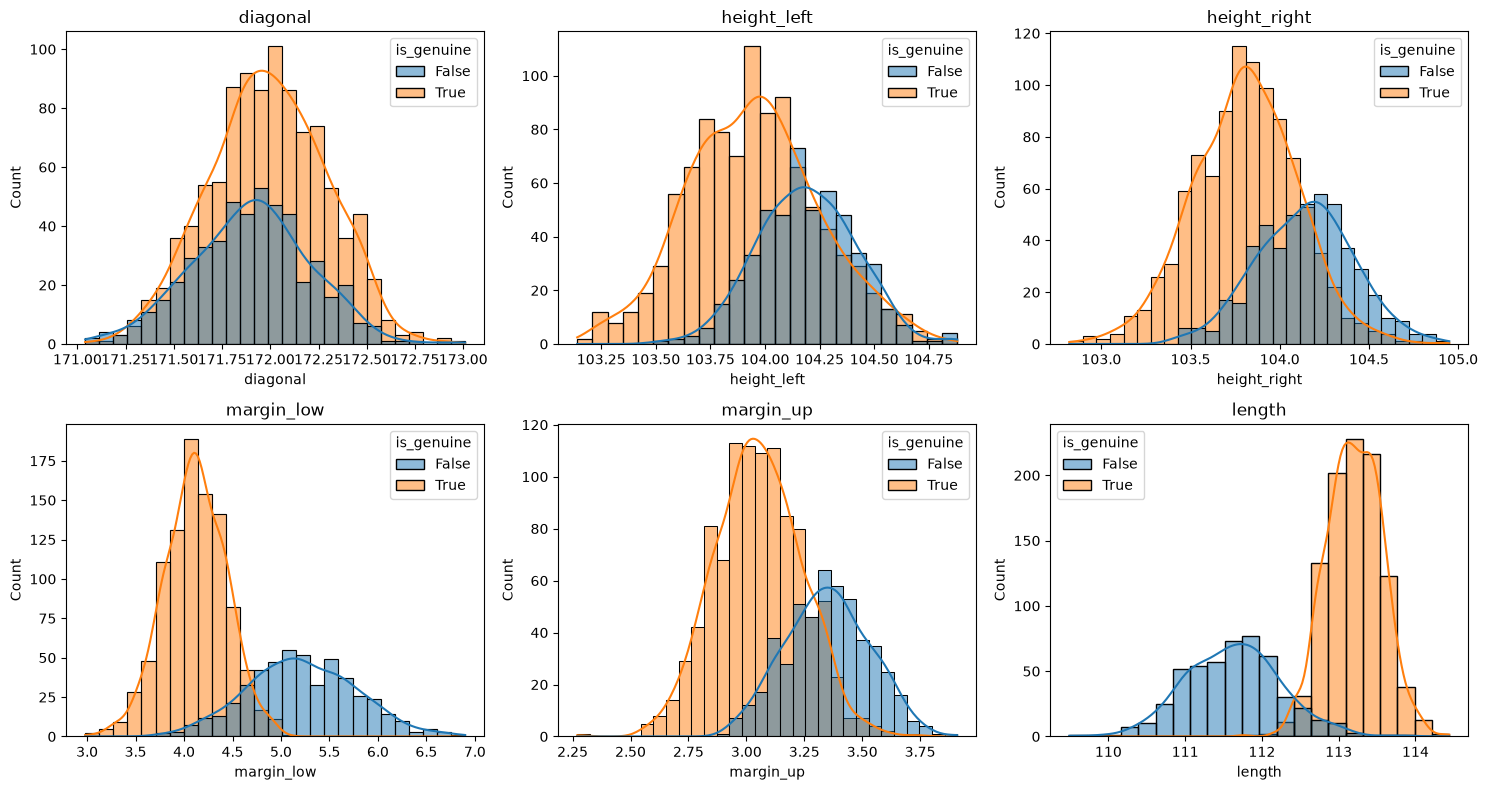

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
variables = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

for ax, var in zip(axes.flatten(), variables):
    sns.histplot(data=df, x=var, hue="is_genuine", kde=True, ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()

**Observation** : certaines variables séparent très nettement les vrais et les faux billets, en particulier `length` et `margin_low`, dont les distributions sont quasiment disjointes entre les deux classes. À l'inverse, `height_left`, `height_right` et `diagonal` se chevauchent fortement et semblent peu discriminantes. `margin_up` montre une séparation modérée. Ces observations confirment l'indice du cahier des charges : certaines variables corrélées à la cible seront plus utiles que d'autres pour la prédiction.


### Corrélations entre les variables

Nous calculons la matrice de corrélation entre les variables géométriques et la variable cible afin d'identifier les variables les plus liées à la nature du billet (vrai/faux).


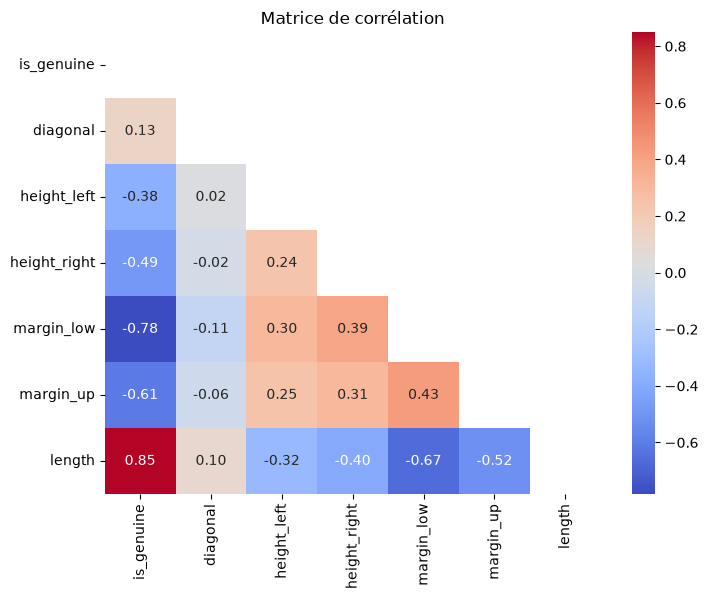

In [8]:
corr = df.corr(numeric_only=False)   # matrice de corrélation (is_genuine inclus, converti en 0/1)

mask = np.triu(np.ones_like(corr, dtype=bool))   # masque pour cacher la partie supérieure

plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

**Observation** : `length` (0.85), `margin_low` (-0.78) et `margin_up` (-0.61) sont les variables les plus corrélées à `is_genuine`. À l'inverse, `diagonal` (0.13) semble peu discriminante.


### Séparation des variables explicatives et de la cible

Nous séparons les données en deux ensembles : X, qui contient les variables géométriques utilisées pour la prédiction, et y, qui contient la variable cible is_genuine indiquant si le billet est vrai ou faux.


In [9]:
X = df.drop(columns="is_genuine")   # variables explicatives (NaN pas encore traités)
y = df["is_genuine"]                 # variable cible

### Séparation en jeu d'entraînement et de test

Nous divisons les données en un jeu d'entraînement, utilisé pour entraîner les modèles, et un jeu de test, conservé pour évaluer leur performance sur des données qu'ils n'ont jamais vues. Nous utilisons stratify=y pour conserver la même proportion de vrais et de faux billets dans les deux jeux.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% des données pour le test
    random_state=42,      # reproductibilité
    stratify=y             # conserve la proportion vrais/faux
)

print(X_train.shape, X_test.shape)

(1200, 6) (300, 6)


### Traitement des valeurs manquantes

La variable margin_low contient 37 valeurs manquantes. Étant fortement corrélée aux autres variables géométriques, nous utilisons un KNNImputer, qui estime chaque valeur manquante à partir des billets les plus similaires sur les autres variables.


In [11]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train.isna().sum()   # vérification qu'il n'y a plus de valeurs manquantes

diagonal        0
height_left     0
height_right    0
margin_low      0
margin_up       0
length          0
dtype: int64

### Standardisation des variables

Nous standardisons les variables explicatives afin que chacune ait une moyenne de 0 et un écart-type de 1. Cette étape est importante pour les modèles sensibles aux écarts d'échelle entre variables, comme la régression logistique, le KNN ou le K-means.


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # apprend la moyenne/écart-type sur le train et transforme
X_test_scaled = scaler.transform(X_test)          # applique la même transformation au test

## Modélisation

### Régression logistique

Nous entraînons un premier modèle de régression logistique sur les données standardisées, puis nous utilisons ce modèle pour prédire la nature des billets du jeu de test.


In [13]:
log_reg = LogisticRegression(max_iter=1000)   # max_iter augmenté pour garantir la convergence

log_reg.fit(X_train_scaled, y_train)           # entraînement du modèle

y_pred_log = log_reg.predict(X_test_scaled)    # prédictions sur le jeu de test

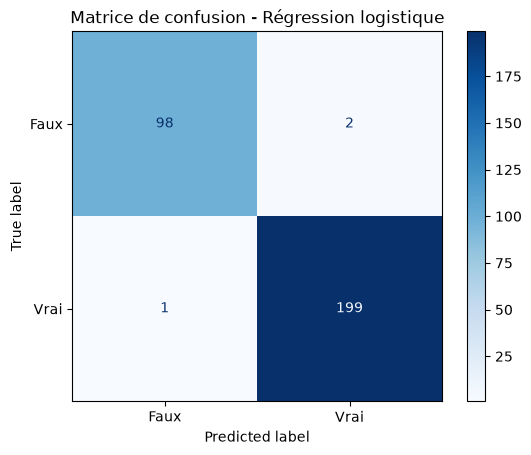

In [14]:
cm = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm, display_labels=["Faux", "Vrai"]).plot(cmap="Blues")
plt.title("Matrice de confusion - Régression logistique")
plt.show()

**Observation** : seulement 3 erreurs sur 300 billets, dont 2 faux billets classés comme vrais. Très peu d'erreurs, mais à surveiller car ce sont justement les faux billets qui passent inaperçus.


### KNN

Nous entraînons un modèle K-nearest neighbors sur les données standardisées, puis nous évaluons ses prédictions sur le jeu de test à l'aide d'une matrice de confusion.


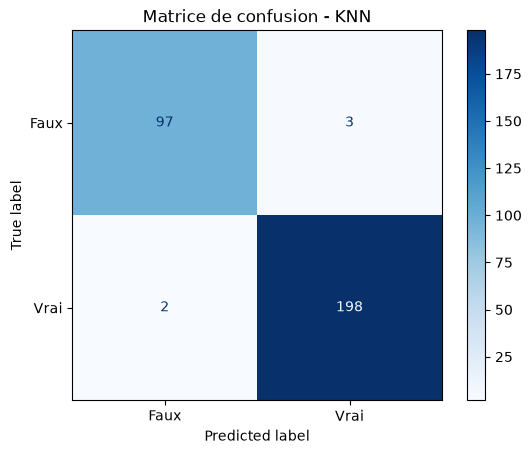

In [15]:
knn = KNeighborsClassifier(n_neighbors=5)   # 5 voisins les plus proches

knn.fit(X_train_scaled, y_train)             # entraînement du modèle

y_pred_knn = knn.predict(X_test_scaled)      # prédictions sur le jeu de test

cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=["Faux", "Vrai"]).plot(cmap="Blues")
plt.title("Matrice de confusion - KNN")
plt.show()

**Observation** : le KNN fait 5 erreurs (3 faux positifs, 2 faux négatifs), légèrement moins bien que la régression logistique sur la détection des faux billets (3 faux billets non détectés contre 2).


### Random Forest

Nous entraînons un modèle Random Forest sur les données standardisées, puis nous évaluons ses prédictions sur le jeu de test à l'aide d'une matrice de confusion.


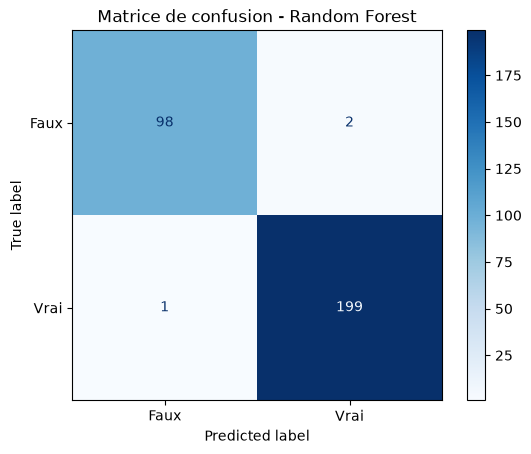

In [16]:
rf = RandomForestClassifier(random_state=42)   # 100 arbres par défaut

rf.fit(X_train, y_train)             # pas besoin des données standardisées pour le Random Forest

y_pred_rf = rf.predict(X_test)       # prédictions sur le jeu de test

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=["Faux", "Vrai"]).plot(cmap="Blues")
plt.title("Matrice de confusion - Random Forest")
plt.show()

**Observation** : le Random Forest obtient des résultats très proches de la régression logistique, avec 1 faux négatif et 2 faux positifs.


### K-means

Nous appliquons un K-means avec 2 clusters sur les données standardisées. Comme l'algorithme ne connaît pas les labels, nous devrons ensuite identifier quel cluster correspond aux vrais billets et lequel correspond aux faux, en comparant avec les vraies valeurs.


In [17]:
kmeans = KMeans(n_clusters=2, random_state=42)   # 2 clusters : vrai / faux

kmeans.fit(X_train_scaled)                        # entraînement (pas de y, non supervisé)

clusters_train = kmeans.labels_                   # cluster attribué à chaque billet du train

In [18]:
pd.crosstab(clusters_train, y_train)   # croise les clusters avec les vraies valeurs

is_genuine,False,True
row_0,,
0,388,7
1,12,793


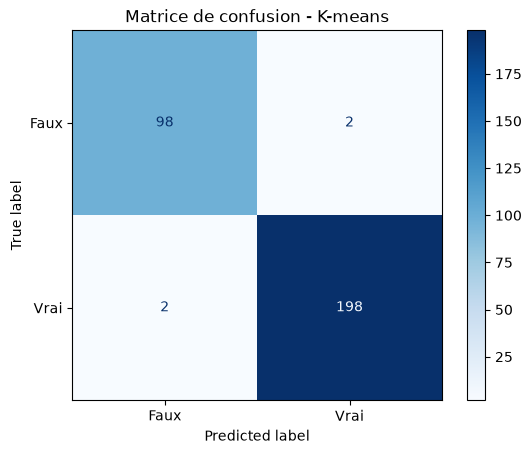

In [19]:
kmeans_test_clusters = kmeans.predict(X_test_scaled)   # assignation des billets du test aux clusters

y_pred_kmeans = np.where(kmeans_test_clusters == 1, True, False)   # cluster 1 = Vrai, cluster 0 = Faux

cm_kmeans = confusion_matrix(y_test, y_pred_kmeans)
ConfusionMatrixDisplay(cm_kmeans, display_labels=["Faux", "Vrai"]).plot(cmap="Blues")
plt.title("Matrice de confusion - K-means")
plt.show()

**Observation** : K-means obtient 4 erreurs au total (2 faux négatifs, 2 faux positifs), un résultat proche de la régression logistique, meilleur que le KNN, mais légèrement moins bon que le Random Forest.


## Évaluation et comparaison des modèles

Nous calculons les principales métriques (accuracy, précision, recall, F1-score) pour chacun des 4 modèles, afin de les comparer et de choisir le plus adapté à notre enjeu métier : détecter un maximum de faux billets.


In [20]:
models_preds = {
    "Régression logistique": y_pred_log,
    "KNN": y_pred_knn,
    "Random Forest": y_pred_rf,
    "K-means": y_pred_kmeans
}

results = []
for name, y_pred in models_preds.items():
    results.append({
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Précision (Faux)": precision_score(y_test, y_pred, pos_label=False),
        "Recall (Faux)": recall_score(y_test, y_pred, pos_label=False),
        "F1-score (Faux)": f1_score(y_test, y_pred, pos_label=False)
    })

results_df = pd.DataFrame(results)
results_df

,Modèle,Accuracy,Précision (Faux),Recall (Faux),F1-score (Faux)
0,Régression logistique,0.990000,0.989899,0.98,0.984925
1,KNN,0.983333,0.979798,0.97,0.974874
2,Random Forest,0.990000,0.989899,0.98,0.984925
3,K-means,0.986667,0.980000,0.98,0.980000


**Observation** : la régression logistique et le Random Forest obtiennent les meilleurs résultats, avec un recall de 0.98 sur les faux billets (98% des faux billets correctement détectés). Le K-means suit de très près, tandis que le KNN est légèrement en retrait avec un recall de 0.97.


## Choix du modèle final

Nous retenons le Random Forest comme modèle final. Il obtient les mêmes performances que la régression logistique (accuracy 0.99, recall 0.98 sur les faux billets), mais présente des avantages pratiques : il ne nécessite pas de standardisation (pipeline plus simple), il est plus robuste face à des données futures légèrement différentes, et il permet d'obtenir facilement l'importance des variables pour expliquer ses décisions.


## Optimisation du modèle final

Nous optimisons les hyperparamètres du Random Forest à l'aide d'une recherche sur grille (GridSearchCV), en optimisant le recall sur la classe "Faux" afin de minimiser le risque de ne pas détecter un faux billet.


In [21]:
from sklearn.model_selection import GridSearchCV

In [22]:
from sklearn.metrics import make_scorer

recall_faux = make_scorer(recall_score, pos_label=False)   # recall calculé sur la classe "Faux"

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring=recall_faux,   # on optimise le recall sur "Faux"
    cv=5
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


### Ajustement du seuil de décision

Plutôt que d'utiliser le seuil par défaut de 0.5, nous testons différents seuils de probabilité pour le Random Forest, afin de viser zéro faux billet classé comme vrai (recall = 1.0 sur la classe Faux).


In [23]:
best_rf = grid_search.best_estimator_   # le meilleur modèle trouvé par GridSearchCV

In [24]:
probas = best_rf.predict_proba(X_test)[:, 1]   # probabilité que le billet soit "Vrai"

for seuil in [0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_seuil = np.where(probas >= seuil, True, False)
    recall_faux = recall_score(y_test, y_pred_seuil, pos_label=False)
    precision_faux = precision_score(y_test, y_pred_seuil, pos_label=False)
    print(f"Seuil {seuil} -> Recall (Faux): {recall_faux:.3f} | Précision (Faux): {precision_faux:.3f}")

Seuil 0.5 -> Recall (Faux): 0.980 | Précision (Faux): 0.990
Seuil 0.6 -> Recall (Faux): 0.980 | Précision (Faux): 0.980
Seuil 0.7 -> Recall (Faux): 0.980 | Précision (Faux): 0.980
Seuil 0.8 -> Recall (Faux): 1.000 | Précision (Faux): 0.962
Seuil 0.9 -> Recall (Faux): 1.000 | Précision (Faux): 0.917


**Observation** : à partir du seuil 0.8, le modèle atteint un recall de 1.0 sur les faux billets (aucun faux billet n'est classé comme vrai), avec une précision encore élevée de 0.962. C'est le seuil retenu pour notre cas d'usage, où l'enjeu prioritaire est de ne laisser passer aucun faux billet.


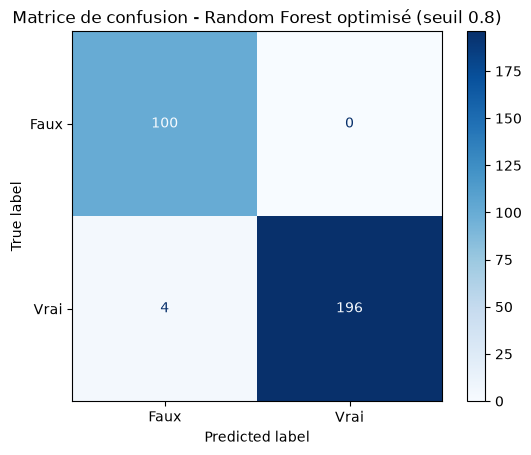

In [25]:
y_pred_final = np.where(probas >= 0.8, True, False)   # application du seuil retenu

cm_final = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm_final, display_labels=["Faux", "Vrai"]).plot(cmap="Blues")
plt.title("Matrice de confusion - Random Forest optimisé (seuil 0.8)")
plt.show()

In [26]:
for seuil in np.arange(0.5, 0.85, 0.05):
    y_pred_seuil = np.where(probas >= seuil, True, False)
    recall_faux = recall_score(y_test, y_pred_seuil, pos_label=False)
    precision_faux = precision_score(y_test, y_pred_seuil, pos_label=False)
    fp = ((y_pred_seuil == True) & (y_test == False)).sum()
    fn = ((y_pred_seuil == False) & (y_test == True)).sum()
    print(f"Seuil {seuil:.2f} -> Recall(Faux): {recall_faux:.3f} | Faux positifs: {fp} | Faux négatifs: {fn}")

Seuil 0.50 -> Recall(Faux): 0.980 | Faux positifs: 2 | Faux négatifs: 1
Seuil 0.55 -> Recall(Faux): 0.980 | Faux positifs: 2 | Faux négatifs: 1
Seuil 0.60 -> Recall(Faux): 0.980 | Faux positifs: 2 | Faux négatifs: 2
Seuil 0.65 -> Recall(Faux): 0.980 | Faux positifs: 2 | Faux négatifs: 2
Seuil 0.70 -> Recall(Faux): 0.980 | Faux positifs: 2 | Faux négatifs: 2
Seuil 0.75 -> Recall(Faux): 0.990 | Faux positifs: 1 | Faux négatifs: 3
Seuil 0.80 -> Recall(Faux): 1.000 | Faux positifs: 0 | Faux négatifs: 4


### Bonus : pipeline avec sélection automatique du meilleur modèle


### Architecture finale du pipeline (bonus)

**Bloc 1 — Validateur de colonnes**

- Vérifie que les 6 colonnes attendues sont présentes
- Lève une erreur claire si une colonne manque entièrement
- Ignore les colonnes en trop

**Bloc 2 — Détecteur de ligne totalement vide**

- Vérifie qu'aucune ligne n'a ses 6 valeurs en NaN simultanément
- Lève une erreur explicite si c'est le cas

**Bloc 3 — Imputation**

- KNNImputer (5 voisins), pour les valeurs manquantes partielles

**Bloc 4 — Sélecteur automatique de modèle**

- Candidats : régression logistique, KNN, Random Forest (K-means exclu, non supervisé)
- Standardisation intégrée individuellement pour la régression logistique et le KNN, absente pour le Random Forest
- Scoring : F-beta (beta=2), favorisant le recall sur "Faux"
- Garde le meilleur modèle entraîné

**Bloc 5 — Décision avec seuil personnalisé**

- Applique notre seuil optimisé (0.8) sur les probabilités, plutôt que le seuil par défaut (0.5)

**Bloc 6 — Assemblage final**

- Tous les blocs sont chaînés dans un seul pipeline utilisable de bout en bout

**Bloc 7 — Visualisation et vérification finale**

- Affichage du pipeline sous forme de schéma (set_config(display="diagram"))
- Matrice de confusion finale pour vérifier que le pipeline complet fonctionne comme attendu


In [27]:
# BLOC 1 - Validateur de colonnes

from sklearn.base import BaseEstimator, TransformerMixin

class ColumnValidator(BaseEstimator, TransformerMixin):
    """
    Vérifie que les colonnes attendues sont présentes.
    Ignore les colonnes en trop. Lève une erreur si une colonne manque.
    """

    def __init__(self, expected_columns):
        self.expected_columns = expected_columns   # liste des 6 colonnes attendues

    def fit(self, X, y=None):
        return self   # rien à apprendre, juste une vérification

    def transform(self, X):
        missing = set(self.expected_columns) - set(X.columns)   # colonnes manquantes
        if missing:
            raise ValueError(f"Colonnes manquantes : {missing}")

        return X[self.expected_columns]   # garde uniquement les colonnes attendues, dans l'ordre

In [28]:
# BLOC 2 - Détecteur de ligne totalement vide

class EmptyRowDetector(BaseEstimator, TransformerMixin):
    """
    Vérifie qu'aucune ligne n'a toutes ses valeurs manquantes.
    Lève une erreur explicite si c'est le cas.
    """

    def fit(self, X, y=None):
        return self   # rien à apprendre

    def transform(self, X):
        fully_empty = X.isna().all(axis=1)   # lignes où toutes les colonnes sont NaN

        if fully_empty.any():
            nb = fully_empty.sum()
            raise ValueError(f"{nb} billet(s) n'ont aucune mesure disponible : impossible de prédire.")

        return X   # rien à transformer, juste une vérification

In [29]:
# BLOC 3 - Imputation des valeurs manquantes

imputer_pipeline = KNNImputer(n_neighbors=5)   # complète les valeurs manquantes partielles

In [30]:
# BLOC 4 - Sélecteur automatique du meilleur modèle

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, fbeta_score

fbeta_faux = make_scorer(fbeta_score, beta=2, pos_label=False)   # priorité au recall sur "Faux"

# Chaque modèle candidat embarque son propre scaler si besoin
# (la régression logistique et le KNN en ont besoin, le Random Forest non)
models_candidats = {
    "Régression logistique": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Random Forest": RandomForestClassifier(random_state=42, max_depth=None, min_samples_split=2, n_estimators=50)
}

class BestModelSelector(BaseEstimator, ClassifierMixin):
    """
    Teste plusieurs modèles candidats, garde celui qui obtient
    le meilleur score (F-beta sur la classe Faux), puis l'entraîne
    sur l'ensemble des données.
    """

    def __init__(self, models, scoring=fbeta_faux, cv=5):
        self.models = models     # dictionnaire {nom: modèle}
        self.scoring = scoring   # scoring utilisé pour comparer
        self.cv = cv              # nombre de découpages en validation croisée

    def fit(self, X, y):
        best_score = -np.inf
        best_model = None
        best_name = None

        for name, model in self.models.items():
            score = cross_val_score(model, X, y, scoring=self.scoring, cv=self.cv).mean()
            print(f"{name} -> score moyen : {score:.3f}")

            if score > best_score:
                best_score = score
                best_model = model
                best_name = name

        print(f"\nModèle retenu automatiquement : {best_name} (score : {best_score:.3f})")

        self.best_model_ = best_model.fit(X, y)   # entraînement du gagnant sur toutes les données
        self.best_name_ = best_name
        return self

    def predict_proba(self, X):
        return self.best_model_.predict_proba(X)

    def predict(self, X):
        return self.best_model_.predict(X)

In [31]:
# BLOC 5 - Application du seuil de décision personnalisé

class ThresholdClassifier(BaseEstimator, ClassifierMixin):
    """
    Enveloppe un modèle (ici le sélecteur) et applique
    un seuil de décision personnalisé sur les probabilités,
    plutôt que le seuil par défaut de 0.5.
    """

    def __init__(self, base_model, threshold=0.8):
        self.base_model = base_model
        self.threshold = threshold

    def fit(self, X, y):
        self.base_model.fit(X, y)
        self.classes_ = np.unique(y)   # nécessaire pour que sklearn reconnaisse le modèle comme entraîné
        return self

    def predict_proba(self, X):
        return self.base_model.predict_proba(X)

    def predict(self, X):
        probas = self.base_model.predict_proba(X)[:, 1]
        return np.where(probas >= self.threshold, True, False)

In [32]:
# BLOC 6 - Assemblage du pipeline final

selector = BestModelSelector(models=models_candidats)
final_model = ThresholdClassifier(base_model=selector, threshold=0.8)

pipeline_complet = make_pipeline(
    ColumnValidator(expected_columns=["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]),
    EmptyRowDetector(),
    imputer_pipeline,
    final_model
)

In [33]:
# BLOC 7 - Visualisation et vérification finale

from sklearn import set_config
set_config(display="diagram")   # affichage visuel du pipeline

pipeline_complet   # affiche le schéma du pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columnvalidator', ...), ('emptyrowdetector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,expected_columns,"['diagonal', 'height_left', ...]"
,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",5
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'uniform'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto theoutput of the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear on themissing indicator even if there are missing values at transform/testtime.",False


Régression logistique -> score moyen : 0.978
KNN -> score moyen : 0.980


Random Forest -> score moyen : 0.982

Modèle retenu automatiquement : Random Forest (score : 0.982)


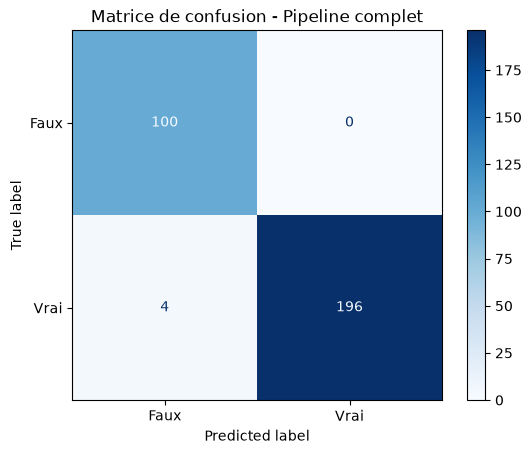

In [34]:
pipeline_complet.fit(X_train, y_train)   # entraîne tout le pipeline (sélection du modèle incluse)

y_pred_pipeline = pipeline_complet.predict(X_test)   # prédictions sur le jeu de test

cm_pipeline = confusion_matrix(y_test, y_pred_pipeline)
ConfusionMatrixDisplay(cm_pipeline, display_labels=["Faux", "Vrai"]).plot(cmap="Blues")
plt.title("Matrice de confusion - Pipeline complet")
plt.show()

## Sauvegarde du modèle final

Nous sauvegardons le pipeline complet entraîné (incluant l'imputation, la sélection automatique du modèle et le seuil personnalisé) dans un fichier .pkl, afin de pouvoir le réutiliser directement dans le script final sans avoir à réentraîner.


In [35]:
import joblib

joblib.dump(pipeline_complet, "../script/pipeline_final.pkl")   # sauvegarde dans le dossier script
print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.
